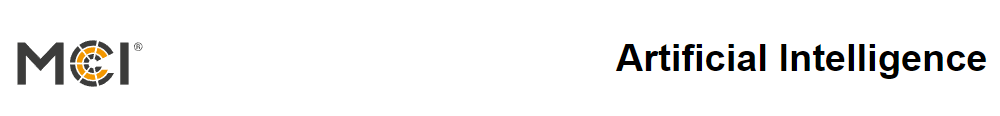

---

# 02 a YOLO Area Segmentation

First: Import all needed packages

https://docs.ultralytics.com/quickstart/#install-ultralytics

https://docs.ultralytics.com/quickstart/#use-ultralytics-with-python

In [1]:
from ultralytics import YOLO
from PIL import Image

## Segmentation

The first task we want to perform is *Image Segmentation*. Therefore we need to define
 * the path to source picture
 * the YOLO model we want to use

In [4]:
# Path to the source image
picpath = "../Data/Test_Images/examplepic2.jpg"

# Load custom trained YOLOv8 model
# different models n, s, m, l, x
model_seg = YOLO('../Network_Development/Models/yolov8n-seg.pt')      # Segmentation

Now we can apply this model to our source image

In [5]:
results_seg = model_seg(picpath)  # predict on an image


image 1/1 c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Segmentation\..\Data\Test_Images\examplepic2.jpg: 384x640 1 person, 1 sports ball, 1 tennis racket, 38.6ms
Speed: 1.8ms preprocess, 38.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


The output of the model tells us:
 * How many objects of each class
 * Processing time (preprocess, inference, postprocess)
 * Shape of the image

Now we can further analyse the results:

In [6]:
results_seg

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 

As with detection, the model returns an Ultralytics object. Basically, the results look identical. The only difference is that Masks is no longer None. We will therefore take a closer look at this new Masks object

In [7]:
results_seg[0].masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8)
orig_shape: (1080, 1920)
shape: torch.Size([3, 384, 640])
xy: [array([[       1038,           6],
       [       1038,          15],
       [       1023,          30],
       ...,
       [       1116,          24],
       [       1107,    

In [8]:
len(results_seg[0].masks.data)

3

In [9]:
results_seg[0].masks.xy[0]

array([[       1038,           6],
       [       1038,          15],
       [       1023,          30],
       ...,
       [       1116,          24],
       [       1107,          15],
       [       1107,           6]], shape=(623, 2), dtype=float32)

Now we want to visualize the results. Therefore the first step is to save the image to a file. The easiest way is to set the inference argument *save* True. Therefore the resulting picture including the boxes will be saved under 'runs\detect\predict'

In [10]:
results_seg = model_seg(source=picpath, save=True)


image 1/1 c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Segmentation\..\Data\Test_Images\examplepic2.jpg: 384x640 1 person, 1 sports ball, 1 tennis racket, 39.1ms
Speed: 2.8ms preprocess, 39.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Segmentation\runs\segment\predict


We can now navigate to the saved file via explorer and open it.

The next task is to visualize the results directly in the notebook. There are different packages and ways of doing this. One package which is easy to use is the Pillow package. We import *Image* from PIL and use it to generate a picture from the results array (plot function: https://docs.ultralytics.com/modes/predict/#working-with-results)

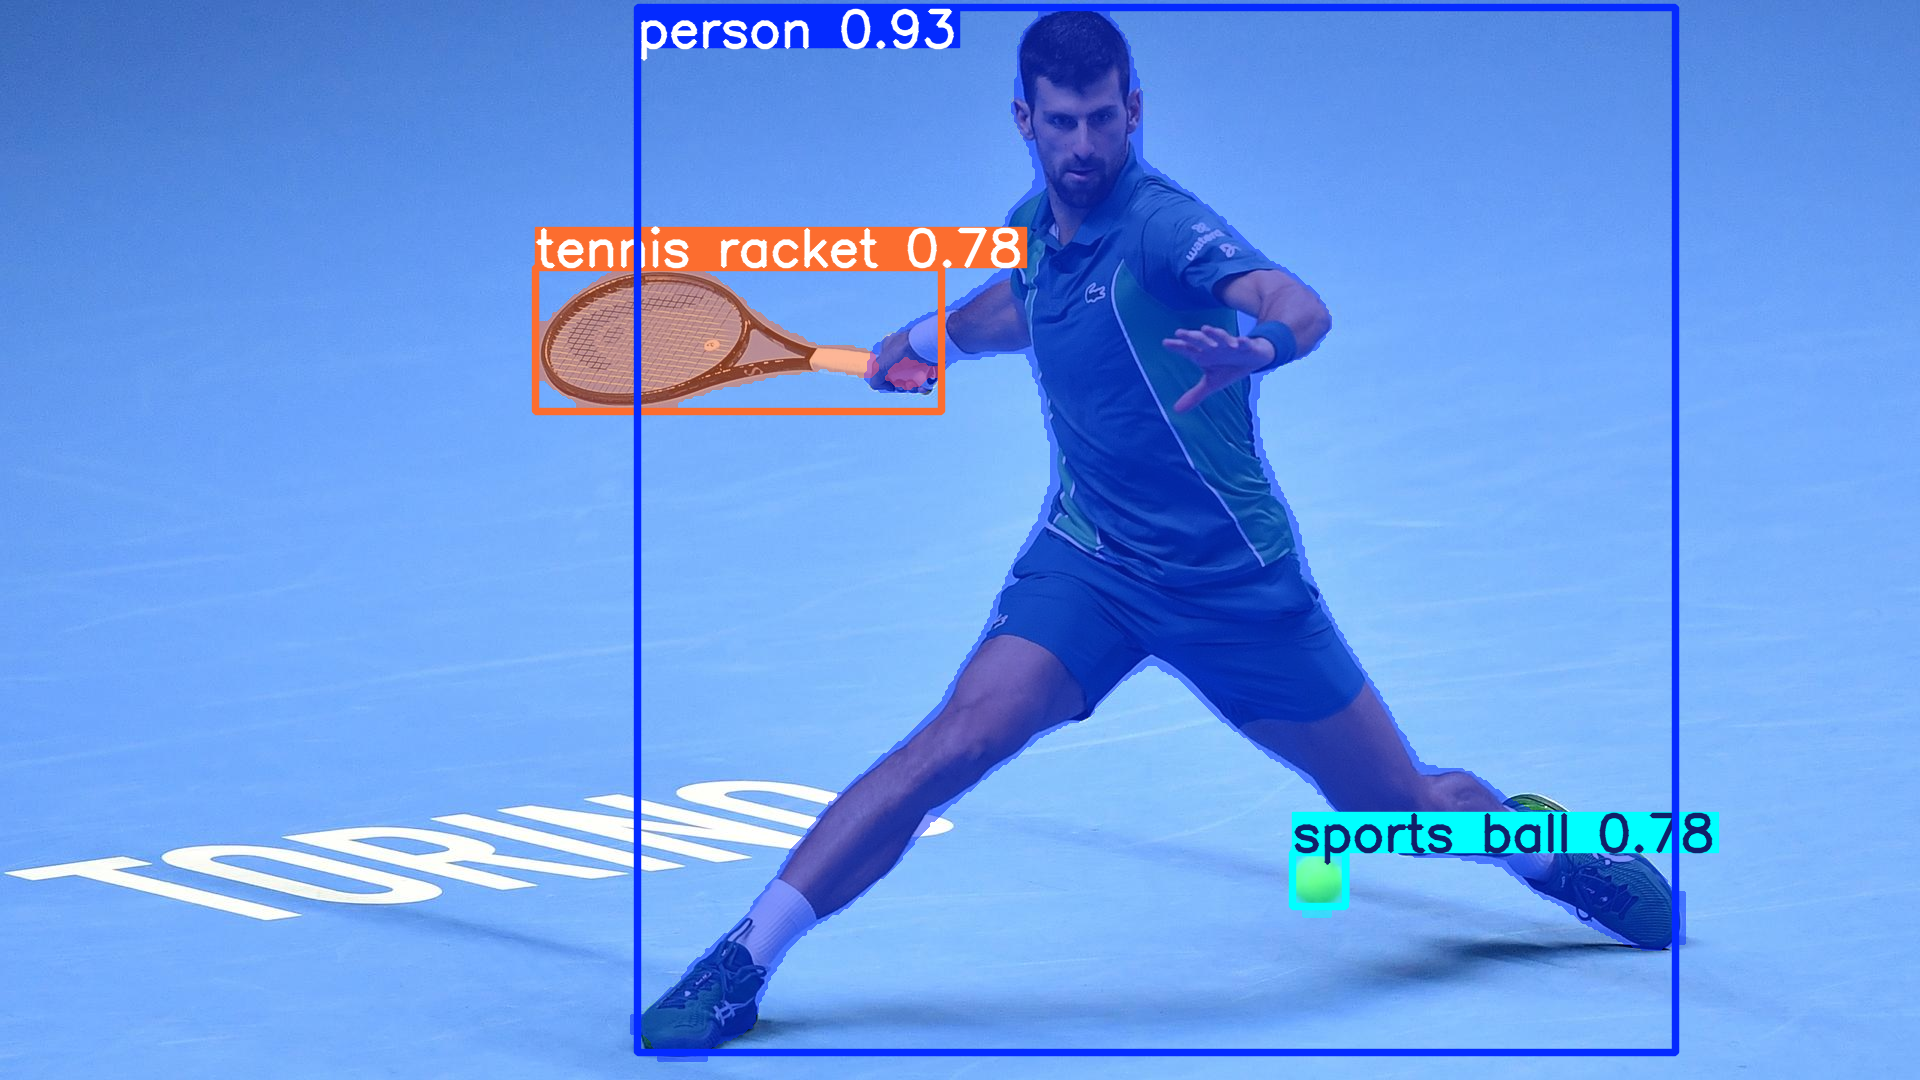

In [11]:
im_array = results_seg[0].plot()
Image.fromarray(im_array[..., ::-1 ])

#### TASK:
Now we play around a little bit. Try the following things:
* Use a different size of the model (s,m,l) --> What can you see?
* Use a picture of your choise
* Use the current yolo segmentation model (26 or higher)